# TAHAP 07 — Chatbot Evaluation, Error Analysis & Scenario Testing

Notebook ini digunakan untuk mengevaluasi pipeline chatbot yang sudah dibangun pada **Tahap 06**. Fokus evaluasi tidak hanya pada apakah fungsi `chatbot_response()` berjalan, tetapi juga apakah respons chatbot sudah sesuai dengan intent, konteks pertanyaan, rekomendasi program studi, dan kebutuhan pengguna.

## 1. Tujuan Tahap 07

Tahap ini bertujuan untuk:

1. Membuat dataset skenario uji chatbot yang lebih lengkap.
2. Menguji fungsi `chatbot_response()` dari Tahap 06.
3. Mengevaluasi ketepatan intent routing.
4. Mengevaluasi kesesuaian respons chatbot terhadap ekspektasi skenario.
5. Melakukan error analysis terhadap kasus gagal atau kurang tepat.
6. Membuat visualisasi hasil evaluasi.
7. Menyimpan seluruh output evaluasi ke folder `reports/stage07/`.

Evaluasi ini penting karena chatbot akademik tidak cukup hanya menghasilkan teks, tetapi harus dapat diuji secara sistematis agar hasilnya dapat dipertanggungjawabkan.

## 2. Desain Evaluasi Chatbot

Alur evaluasi pada notebook ini adalah sebagai berikut:

1. Load pipeline chatbot dari notebook Tahap 06.
2. Membuat dataset skenario uji.
3. Menjalankan setiap skenario ke fungsi `chatbot_response()`.
4. Membandingkan output aktual dengan ekspektasi:
   - `expected_intent`
   - `expected_top_program`
   - `expected_contains`
   - `expected_not_contains`
5. Menghitung metrik evaluasi:
   - Intent accuracy
   - Response content accuracy
   - Top program accuracy
   - Overall pass rate
   - Strict pass rate
6. Membuat error analysis.
7. Membuat visualisasi dan report.

Catatan: evaluasi ini bersifat **rule-assisted functional evaluation**, karena chatbot masih menggunakan pipeline baseline akademik dengan dataset yang relatif kecil.

In [1]:
# ============================================================
# 1. Import Library
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import re
import warnings

import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

print("Library berhasil di-load.")

Library berhasil di-load.


In [2]:
# ============================================================
# 2. Konfigurasi Path Project
# ============================================================

CURRENT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, project root adalah parent folder.
# Jika notebook dijalankan dari root project, gunakan current directory.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
STAGE06_NOTEBOOK_PATH = NOTEBOOK_DIR / "06_chatbot_pipeline_integration.ipynb"

STAGE07_REPORT_DIR = PROJECT_ROOT / "reports" / "stage07"
STAGE07_FIGURE_DIR = STAGE07_REPORT_DIR / "figures"

STAGE07_REPORT_DIR.mkdir(parents=True, exist_ok=True)
STAGE07_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT           :", PROJECT_ROOT)
print("NOTEBOOK_DIR           :", NOTEBOOK_DIR)
print("STAGE06_NOTEBOOK_PATH  :", STAGE06_NOTEBOOK_PATH)
print("STAGE07_REPORT_DIR     :", STAGE07_REPORT_DIR)
print("STAGE07_FIGURE_DIR     :", STAGE07_FIGURE_DIR)

PROJECT_ROOT           : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant
NOTEBOOK_DIR           : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\notebooks
STAGE06_NOTEBOOK_PATH  : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\notebooks\06_chatbot_pipeline_integration.ipynb
STAGE07_REPORT_DIR     : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07
STAGE07_FIGURE_DIR     : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\figures


### Interpretasi Konfigurasi Path

Cell di atas memastikan notebook dapat dijalankan baik dari folder root project maupun dari folder `notebooks/`. Output Tahap 07 akan disimpan pada:

- `reports/stage07/`
- `reports/stage07/figures/`

In [3]:
# ============================================================
# 3. Load Pipeline Chatbot dari Notebook Tahap 06
# ============================================================

if not STAGE06_NOTEBOOK_PATH.exists():
    raise FileNotFoundError(
        "Notebook Tahap 06 tidak ditemukan. Pastikan file berikut tersedia:\n"
        f"{STAGE06_NOTEBOOK_PATH}"
    )

print("Menjalankan ulang code cell dari Tahap 06 untuk memuat pipeline chatbot...")

stage06_nb = nbformat.read(STAGE06_NOTEBOOK_PATH, as_version=4)
executed_cells = []

for idx, cell in enumerate(stage06_nb.cells):
    if cell.cell_type == "code" and cell.source.strip():
        try:
            exec(cell.source, globals())
            executed_cells.append(idx)
        except Exception as exc:
            raise RuntimeError(
                f"Gagal menjalankan code cell ke-{idx} dari notebook Tahap 06. "
                "Periksa kembali dataset dan model artifact Tahap 04–05."
            ) from exc

required_objects = [
    "chatbot_response",
    "route_intent",
    "predict_intent",
    "recommend_programs",
    "program_profiles_df",
    "career_df",
    "skill_df",
    "roadmap_df"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise RuntimeError(
        "Beberapa objek penting dari Tahap 06 belum berhasil dimuat: "
        + ", ".join(missing_objects)
    )

# Kembalikan variabel report ke folder Tahap 07 agar output tidak tercampur dengan stage06.
REPORT_DIR = STAGE07_REPORT_DIR
FIGURE_DIR = STAGE07_FIGURE_DIR

print("Pipeline Tahap 06 berhasil dimuat.")
print("Jumlah code cell Tahap 06 yang dieksekusi:", len(executed_cells))
print("Jumlah program studi pada recommender:", len(program_profiles_df))

Menjalankan ulang code cell dari Tahap 06 untuk memuat pipeline chatbot...
Library berhasil di-load.
PROJECT_ROOT: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant
DATA_DIR    : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\processed
MODEL_DIR   : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\models
REPORT_DIR  : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage06


,dataset,path,jumlah_baris,jumlah_kolom
0,intent,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,12,21
1,program,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,5,22
2,program_profiles,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,5,25
3,career,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,5,15
4,skill,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,7,15
5,roadmap,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,6,15
6,normalisasi,D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TU...,18,10


Model intent       : LinearSVC
Vectorizer intent  : TfidfVectorizer
Vectorizer recsys  : TfidfVectorizer
Matrix recsys shape: (5, 795)
Best model stage04 : LinearSVC
Method stage05     : Content-Based Filtering using TF-IDF, Cosine Similarity, and Rule-Based Structured Scoring


,dataframe,required_column,status
0,intent_df,utterance,OK
1,intent_df,intent_label,OK
2,intent_df,utterance_preprocessed,OK
3,program_profiles_df,program_id,OK
4,program_profiles_df,nama_program_studi,OK
5,program_profiles_df,deskripsi_singkat,OK
6,program_profiles_df,program_profile_text,OK
7,career_df,karier_id,OK
8,career_df,nama_karier,OK
9,career_df,program_studi_relevan_id_list,OK


Schema minimum sudah sesuai.
Input       : Aku seneng ngoding sama statistik, cocoknya kuliah apa ya?
Normalized  : saya suka pemrograman sama statistik cocoknya program studi apa ya
Preprocessed: suka pemrograman sama statistik program studi
--------------------------------------------------------------------------------
Input       : Aku pengin dadi analis data, jurusan sing pas apa?
Normalized  : saya ingin menjadi analis data program studi yang pas apa
Preprocessed: menjadi analis data program studi
--------------------------------------------------------------------------------
Input       : Abdi resep komputer jeung angka, prodi naon nu cocog?
Normalized  : abdi suka komputer jeung angka program studi apa nu cocog
Preprocessed: abdi suka komputer jeung angka program studi nu cocog
--------------------------------------------------------------------------------
Input: Halo, saya mau tanya jurusan kuliah.
{'final_intent': 'sapaan', 'routing_source': 'rule_based', 'model_result': {'

,scenario,final_intent,routing_source,model_predicted_intent,model_confidence,rule_intent,rule_confidence
0,Sapaan,sapaan,rule_based,sapaan,0.2121,sapaan,0.6
1,Rekomendasi prodi formal,rekomendasi_prodi,rule_based,rekomendasi_prodi,0.2424,rekomendasi_prodi,1.0
2,Rekomendasi prodi non-formal,rekomendasi_prodi,rule_based,rekomendasi_prodi,0.2287,rekomendasi_prodi,1.0
3,Bahasa Jawa umum,rekomendasi_prodi,rule_based,rekomendasi_prodi,0.1643,rekomendasi_prodi,0.8
4,Bahasa Sunda umum,rekomendasi_prodi,rule_based,rekomendasi_prodi,0.2565,rekomendasi_prodi,1.0
5,Roadmap belajar,roadmap_belajar,rule_based,roadmap_belajar,0.2046,roadmap_belajar,0.8
6,Prospek karier,prospek_karier,rule_based,prospek_karier,0.2087,prospek_karier,0.6
7,Skill awal,skill_awal,rule_based,skill_awal,0.2718,skill_awal,0.6
8,Info program studi,info_program_studi,rule_based,info_program_studi,0.2579,info_program_studi,0.8
9,Fallback,fallback,fallback_threshold,rekomendasi_prodi,0.1477,None,0.0


Report berhasil disimpan:
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage06\chatbot_test_results_stage06.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage06\chatbot_sample_responses_stage06.md
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage06\stage06_summary.txt


,file,exists,size_bytes
0,notebooks\06_chatbot_pipeline_integration.ipynb,True,110940
1,reports\stage06\chatbot_test_results_stage06.csv,True,8667
2,reports\stage06\chatbot_sample_responses_stage...,True,8211
3,reports\stage06\stage06_summary.txt,True,1675
4,reports\stage06\stage06_output_checklist.csv,True,258


Checklist disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage06\stage06_output_checklist.csv
Pipeline Tahap 06 berhasil dimuat.
Jumlah code cell Tahap 06 yang dieksekusi: 16
Jumlah program studi pada recommender: 5


### Interpretasi Load Pipeline

Tahap 07 menggunakan fungsi dan objek yang sudah dibangun pada Tahap 06, terutama:

- `chatbot_response()`
- `route_intent()`
- `predict_intent()`
- `recommend_programs()`
- dataset program studi, karier, skill, dan roadmap

Dengan cara ini, evaluasi dilakukan terhadap pipeline yang sama dengan pipeline chatbot utama, bukan terhadap fungsi tiruan.

In [4]:
# ============================================================
# 4. Membuat Dataset Skenario Uji Chatbot
# ============================================================

scenario_rows = [
    {
        "test_id": "TC001",
        "scenario_group": "sapaan",
        "user_input": "Halo kak, saya mau tanya tentang pilihan jurusan kuliah.",
        "expected_intent": "sapaan",
        "expected_top_program": "",
        "expected_contains": "Halo;EduPath",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Mengukur respons awal chatbot terhadap sapaan formal."
    },
    {
        "test_id": "TC002",
        "scenario_group": "sapaan",
        "user_input": "Assalamualaikum, boleh tanya rekomendasi kuliah?",
        "expected_intent": "sapaan",
        "expected_top_program": "",
        "expected_contains": "Halo;rekomendasi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Mengukur sapaan bernuansa salam."
    },
    {
        "test_id": "TC003",
        "scenario_group": "rekomendasi_formal",
        "user_input": "Saya suka matematika, statistik, data, dan ingin menjadi data scientist. Program studi apa yang cocok?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Sains Data",
        "expected_contains": "rekomendasi;program studi;Catatan",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Rekomendasi untuk profil data science."
    },
    {
        "test_id": "TC004",
        "scenario_group": "rekomendasi_formal",
        "user_input": "Saya tertarik coding, algoritma, komputer, dan membuat aplikasi.",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Rekomendasi untuk profil software engineering."
    },
    {
        "test_id": "TC005",
        "scenario_group": "rekomendasi_formal",
        "user_input": "Saya suka proses bisnis, teknologi, analisis kebutuhan, dan ingin menjadi business analyst.",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Sistem Informasi",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Rekomendasi untuk profil sistem informasi dan business analyst."
    },
    {
        "test_id": "TC006",
        "scenario_group": "rekomendasi_formal",
        "user_input": "Saya suka matematika, peluang, statistik, dan analisis angka.",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Profil statistik dapat mengarah ke Statistika atau Sains Data."
    },
    {
        "test_id": "TC007",
        "scenario_group": "rekomendasi_formal",
        "user_input": "Saya suka menggambar, desain visual, membuat konten digital, dan warna.",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Desain Komunikasi Visual",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Rekomendasi untuk profil desain visual."
    },
    {
        "test_id": "TC008",
        "scenario_group": "rekomendasi_nonformal",
        "user_input": "Aku seneng ngoding dan bikin aplikasi, cocok kuliah apa ya?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Input non-formal Bahasa Indonesia."
    },
    {
        "test_id": "TC009",
        "scenario_group": "rekomendasi_nonformal",
        "user_input": "Aku suka ngolah data, bikin dashboard, sama lihat pola angka.",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Sains Data",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Input non-formal untuk profil analitik data."
    },
    {
        "test_id": "TC010",
        "scenario_group": "bahasa_jawa",
        "user_input": "Aku pengin dadi analis data, jurusan sing pas apa?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Sains Data",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Input Bahasa Jawa umum untuk data analyst."
    },
    {
        "test_id": "TC011",
        "scenario_group": "bahasa_jawa",
        "user_input": "Aku seneng komputer lan nggawe aplikasi, prodi sing cocok apa?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Input Bahasa Jawa umum untuk software/application development."
    },
    {
        "test_id": "TC012",
        "scenario_group": "bahasa_sunda",
        "user_input": "Abdi resep komputer jeung angka, prodi naon nu cocog?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Sains Data",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Input Bahasa Sunda umum untuk komputer dan angka."
    },
    {
        "test_id": "TC013",
        "scenario_group": "bahasa_sunda",
        "user_input": "Abdi resep desain gambar jeung konten digital, jurusan naon nu pas?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "Desain Komunikasi Visual",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.00,
        "notes": "Input Bahasa Sunda umum untuk desain visual."
    },
    {
        "test_id": "TC014",
        "scenario_group": "roadmap",
        "user_input": "Kalau saya mau masuk Sains Data, harus belajar apa dulu?",
        "expected_intent": "roadmap_belajar",
        "expected_top_program": "Sains Data",
        "expected_contains": "Roadmap belajar awal;Fase",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Roadmap belajar Sains Data."
    },
    {
        "test_id": "TC015",
        "scenario_group": "roadmap",
        "user_input": "Roadmap belajar Teknik Informatika dari awal itu seperti apa?",
        "expected_intent": "roadmap_belajar",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "Roadmap belajar awal;Fase",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Roadmap belajar Teknik Informatika."
    },
    {
        "test_id": "TC016",
        "scenario_group": "prospek_karier",
        "user_input": "Prospek kerja Sistem Informasi itu apa saja?",
        "expected_intent": "prospek_karier",
        "expected_top_program": "Sistem Informasi",
        "expected_contains": "Prospek karier;Tugas utama",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Prospek karier untuk Sistem Informasi."
    },
    {
        "test_id": "TC017",
        "scenario_group": "prospek_karier",
        "user_input": "Kalau kuliah Teknik Informatika nanti kerja apa?",
        "expected_intent": "prospek_karier",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "Prospek karier",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Prospek karier untuk Teknik Informatika."
    },
    {
        "test_id": "TC018",
        "scenario_group": "skill_awal",
        "user_input": "Skill awal untuk menjadi UI UX Designer apa saja?",
        "expected_intent": "skill_awal",
        "expected_top_program": "Desain Komunikasi Visual",
        "expected_contains": "Skill awal;Estimasi belajar",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Skill awal untuk UI/UX atau DKV."
    },
    {
        "test_id": "TC019",
        "scenario_group": "skill_awal",
        "user_input": "Kalau ingin belajar Sains Data, skill dasar apa yang perlu saya kuasai?",
        "expected_intent": "skill_awal",
        "expected_top_program": "Sains Data",
        "expected_contains": "Skill awal;Estimasi belajar",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Skill awal untuk Sains Data."
    },
    {
        "test_id": "TC020",
        "scenario_group": "info_program_studi",
        "user_input": "Apa itu Teknik Informatika?",
        "expected_intent": "info_program_studi",
        "expected_top_program": "Teknik Informatika",
        "expected_contains": "Informasi singkat;Deskripsi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Informasi program studi Teknik Informatika."
    },
    {
        "test_id": "TC021",
        "scenario_group": "info_program_studi",
        "user_input": "Jelaskan Sistem Informasi mempelajari apa.",
        "expected_intent": "info_program_studi",
        "expected_top_program": "Sistem Informasi",
        "expected_contains": "Informasi singkat;Deskripsi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Informasi program studi Sistem Informasi."
    },
    {
        "test_id": "TC022",
        "scenario_group": "info_program_studi",
        "user_input": "Info tentang Desain Komunikasi Visual dong.",
        "expected_intent": "info_program_studi",
        "expected_top_program": "Desain Komunikasi Visual",
        "expected_contains": "Informasi singkat;Deskripsi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Informasi program studi DKV."
    },
    {
        "test_id": "TC023",
        "scenario_group": "klarifikasi_minat",
        "user_input": "Saya masih bingung dan belum tahu minat saya cocok ke jurusan apa.",
        "expected_intent": "klarifikasi_minat",
        "expected_top_program": "",
        "expected_contains": "mata pelajaran;hobi;karier",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Chatbot perlu meminta klarifikasi minat."
    },
    {
        "test_id": "TC024",
        "scenario_group": "klarifikasi_minat",
        "user_input": "Belum tau minat saya apa, masih ragu mau kuliah apa.",
        "expected_intent": "klarifikasi_minat",
        "expected_top_program": "",
        "expected_contains": "mata pelajaran;hobi;karier",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Input kebingungan pemilihan jurusan."
    },
    {
        "test_id": "TC025",
        "scenario_group": "fallback",
        "user_input": "Saya ingin beli sepatu olahraga.",
        "expected_intent": "fallback",
        "expected_top_program": "",
        "expected_contains": "Maaf;saya belum memahami",
        "expected_not_contains": "Berikut rekomendasi",
        "min_routing_confidence": 0.00,
        "notes": "Pertanyaan di luar domain chatbot."
    },
    {
        "test_id": "TC026",
        "scenario_group": "fallback",
        "user_input": "Resep nasi goreng yang enak bagaimana?",
        "expected_intent": "fallback",
        "expected_top_program": "",
        "expected_contains": "Maaf",
        "expected_not_contains": "Berikut rekomendasi",
        "min_routing_confidence": 0.00,
        "notes": "Pertanyaan kuliner di luar domain."
    },
    {
        "test_id": "TC027",
        "scenario_group": "edge_case",
        "user_input": "   ",
        "expected_intent": "fallback",
        "expected_top_program": "",
        "expected_contains": "Maaf",
        "expected_not_contains": "Berikut rekomendasi",
        "min_routing_confidence": 0.00,
        "notes": "Input kosong atau hanya spasi."
    },
    {
        "test_id": "TC028",
        "scenario_group": "edge_case",
        "user_input": "asdf qwerty zzz jurusan",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "",
        "expected_contains": "rekomendasi",
        "expected_not_contains": "",
        "min_routing_confidence": 0.00,
        "notes": "Input noise tetapi mengandung kata jurusan."
    },
    {
        "test_id": "TC029",
        "scenario_group": "mixed_interest",
        "user_input": "Saya suka data tetapi juga suka desain, enaknya pilih prodi apa?",
        "expected_intent": "rekomendasi_prodi",
        "expected_top_program": "",
        "expected_contains": "rekomendasi;program studi",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Minat campuran; cukup dievaluasi intent dan struktur respons."
    },
    {
        "test_id": "TC030",
        "scenario_group": "prospek_karier",
        "user_input": "Apa saja prospek kerja Sains Data?",
        "expected_intent": "prospek_karier",
        "expected_top_program": "Sains Data",
        "expected_contains": "Prospek karier",
        "expected_not_contains": "Maaf",
        "min_routing_confidence": 0.40,
        "notes": "Prospek karier untuk Sains Data."
    },
]

scenario_df = pd.DataFrame(scenario_rows)

scenario_path = STAGE07_REPORT_DIR / "chatbot_evaluation_scenarios_stage07.csv"
scenario_df.to_csv(scenario_path, index=False, encoding="utf-8-sig")

print("Jumlah skenario uji:", len(scenario_df))
print("Dataset skenario disimpan ke:", scenario_path)
display(scenario_df)

Jumlah skenario uji: 30
Dataset skenario disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_evaluation_scenarios_stage07.csv


,test_id,scenario_group,user_input,expected_intent,expected_top_program,expected_contains,expected_not_contains,min_routing_confidence,notes
0,TC001,sapaan,"Halo kak, saya mau tanya tentang pilihan jurus...",sapaan,,Halo;EduPath,Maaf,0.4,Mengukur respons awal chatbot terhadap sapaan ...
1,TC002,sapaan,"Assalamualaikum, boleh tanya rekomendasi kuliah?",sapaan,,Halo;rekomendasi,Maaf,0.4,Mengukur sapaan bernuansa salam.
2,TC003,rekomendasi_formal,"Saya suka matematika, statistik, data, dan ing...",rekomendasi_prodi,Sains Data,rekomendasi;program studi;Catatan,Maaf,0.4,Rekomendasi untuk profil data science.
3,TC004,rekomendasi_formal,"Saya tertarik coding, algoritma, komputer, dan...",rekomendasi_prodi,Teknik Informatika,rekomendasi;program studi,Maaf,0.0,Rekomendasi untuk profil software engineering.
4,TC005,rekomendasi_formal,"Saya suka proses bisnis, teknologi, analisis k...",rekomendasi_prodi,Sistem Informasi,rekomendasi;program studi,Maaf,0.0,Rekomendasi untuk profil sistem informasi dan ...
5,TC006,rekomendasi_formal,"Saya suka matematika, peluang, statistik, dan ...",rekomendasi_prodi,,rekomendasi;program studi,Maaf,0.0,Profil statistik dapat mengarah ke Statistika ...
6,TC007,rekomendasi_formal,"Saya suka menggambar, desain visual, membuat k...",rekomendasi_prodi,Desain Komunikasi Visual,rekomendasi;program studi,Maaf,0.0,Rekomendasi untuk profil desain visual.
7,TC008,rekomendasi_nonformal,"Aku seneng ngoding dan bikin aplikasi, cocok k...",rekomendasi_prodi,Teknik Informatika,rekomendasi;program studi,Maaf,0.4,Input non-formal Bahasa Indonesia.
8,TC009,rekomendasi_nonformal,"Aku suka ngolah data, bikin dashboard, sama li...",rekomendasi_prodi,Sains Data,rekomendasi;program studi,Maaf,0.0,Input non-formal untuk profil analitik data.
9,TC010,bahasa_jawa,"Aku pengin dadi analis data, jurusan sing pas ...",rekomendasi_prodi,Sains Data,rekomendasi;program studi,Maaf,0.4,Input Bahasa Jawa umum untuk data analyst.


### Interpretasi Dataset Skenario Uji

Dataset skenario uji dibuat untuk mencakup beberapa kondisi penting:

- Sapaan
- Rekomendasi program studi formal
- Rekomendasi program studi non-formal
- Input Bahasa Jawa umum
- Input Bahasa Sunda umum
- Roadmap belajar
- Prospek karier
- Skill awal
- Informasi program studi
- Klarifikasi minat
- Fallback
- Edge case

Kolom `expected_contains` dan `expected_not_contains` digunakan untuk mengevaluasi kualitas respons secara sederhana. Pendekatan ini tidak mengukur kualitas bahasa secara semantik penuh, tetapi cukup kuat untuk validasi fungsional baseline chatbot.

In [5]:
# ============================================================
# 5. Helper Function Evaluasi Respons Chatbot
# ============================================================

def split_expectation(value: str) -> list:
    """Memecah ekspektasi berbasis delimiter titik koma."""
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [item.strip() for item in text.split(";") if item.strip()]


def normalize_eval_text(text: str) -> str:
    """Normalisasi teks untuk evaluasi berbasis pencocokan kata/frasa."""
    if "clean_text" in globals():
        return clean_text(text)
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def contains_all_terms(response_text: str, expected_terms: list) -> bool:
    """Memastikan semua frasa ekspektasi muncul pada respons."""
    response_clean = normalize_eval_text(response_text)

    for term in expected_terms:
        term_clean = normalize_eval_text(term)
        if term_clean and term_clean not in response_clean:
            return False

    return True


def contains_no_forbidden_terms(response_text: str, forbidden_terms: list) -> bool:
    """Memastikan frasa yang tidak diharapkan tidak muncul pada respons."""
    response_clean = normalize_eval_text(response_text)

    for term in forbidden_terms:
        term_clean = normalize_eval_text(term)
        if term_clean and term_clean in response_clean:
            return False

    return True


def extract_top_program_from_result(result: dict) -> str:
    """Mengambil program studi teratas dari payload atau response_text."""
    response_text = str(result.get("response_text", ""))
    payload = result.get("payload", None)

    # Jika payload berupa DataFrame rekomendasi atau info program.
    if isinstance(payload, pd.DataFrame) and not payload.empty:
        if "nama_program_studi" in payload.columns:
            value = payload.iloc[0].get("nama_program_studi", "")
            if pd.notna(value) and str(value).strip():
                return str(value).strip()

    # Fallback: scan nama program studi dari response text.
    if "program_profiles_df" in globals() and "nama_program_studi" in program_profiles_df.columns:
        response_clean = normalize_eval_text(response_text)

        for program_name in program_profiles_df["nama_program_studi"].dropna().unique():
            program_clean = normalize_eval_text(program_name)
            if program_clean and program_clean in response_clean:
                return str(program_name).strip()

    return ""


def get_routing_confidence(result: dict) -> float:
    """Mengambil confidence sesuai sumber routing final."""
    routing_source = result.get("routing_source", "")

    if routing_source == "rule_based":
        return float(result.get("rule_confidence", 0.0) or 0.0)

    if routing_source == "model":
        return float(result.get("model_confidence", 0.0) or 0.0)

    # Fallback threshold tidak selalu memiliki confidence eksplisit.
    return 0.0


def evaluate_single_scenario(row: pd.Series) -> dict:
    """Menjalankan satu skenario dan mengembalikan hasil evaluasi."""
    runtime_error = ""

    try:
        result = chatbot_response(row["user_input"], top_n=3, return_dict=True)
    except Exception as exc:
        result = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "user_input": row["user_input"],
            "final_intent": "runtime_error",
            "routing_source": "runtime_error",
            "model_predicted_intent": "",
            "model_confidence": 0.0,
            "rule_intent": "",
            "rule_confidence": 0.0,
            "matched_rule_keywords": "",
            "processed_text": "",
            "response_text": str(exc),
            "payload": None
        }
        runtime_error = str(exc)

    response_text = str(result.get("response_text", ""))
    expected_contains = split_expectation(row.get("expected_contains", ""))
    expected_not_contains = split_expectation(row.get("expected_not_contains", ""))

    final_intent = str(result.get("final_intent", ""))
    expected_intent = str(row.get("expected_intent", ""))

    intent_correct = final_intent == expected_intent
    response_not_empty = bool(response_text.strip())
    contains_ok = contains_all_terms(response_text, expected_contains)
    not_contains_ok = contains_no_forbidden_terms(response_text, expected_not_contains)
    response_content_ok = response_not_empty and contains_ok and not_contains_ok

    expected_top_program = str(row.get("expected_top_program", "")).strip()
    actual_top_program = extract_top_program_from_result(result)

    top_program_applicable = bool(expected_top_program)
    if top_program_applicable:
        expected_program_clean = normalize_eval_text(expected_top_program)
        actual_program_clean = normalize_eval_text(actual_top_program)
        response_clean = normalize_eval_text(response_text)

        top_program_correct = (
            expected_program_clean == actual_program_clean
            or expected_program_clean in response_clean
        )
    else:
        top_program_correct = True

    routing_confidence = get_routing_confidence(result)
    min_routing_confidence = float(row.get("min_routing_confidence", 0.0) or 0.0)
    confidence_ok = routing_confidence >= min_routing_confidence

    overall_pass = intent_correct and response_content_ok and top_program_correct
    strict_pass = overall_pass and confidence_ok

    return {
        "test_id": row["test_id"],
        "scenario_group": row["scenario_group"],
        "user_input": row["user_input"],
        "expected_intent": expected_intent,
        "final_intent": final_intent,
        "intent_correct": intent_correct,
        "routing_source": result.get("routing_source", ""),
        "model_predicted_intent": result.get("model_predicted_intent", ""),
        "model_confidence": float(result.get("model_confidence", 0.0) or 0.0),
        "rule_intent": result.get("rule_intent", ""),
        "rule_confidence": float(result.get("rule_confidence", 0.0) or 0.0),
        "routing_confidence": routing_confidence,
        "min_routing_confidence": min_routing_confidence,
        "confidence_ok": confidence_ok,
        "matched_rule_keywords": result.get("matched_rule_keywords", ""),
        "processed_text": result.get("processed_text", ""),
        "expected_top_program": expected_top_program,
        "actual_top_program": actual_top_program,
        "top_program_applicable": top_program_applicable,
        "top_program_correct": top_program_correct,
        "expected_contains": row.get("expected_contains", ""),
        "expected_not_contains": row.get("expected_not_contains", ""),
        "response_not_empty": response_not_empty,
        "contains_ok": contains_ok,
        "not_contains_ok": not_contains_ok,
        "response_content_ok": response_content_ok,
        "overall_pass": overall_pass,
        "strict_pass": strict_pass,
        "response_length_chars": len(response_text),
        "response_text": response_text,
        "runtime_error": runtime_error,
        "notes": row.get("notes", "")
    }

print("Helper function evaluasi berhasil dibuat.")

Helper function evaluasi berhasil dibuat.


In [6]:
# ============================================================
# 6. Menjalankan Evaluasi Seluruh Skenario
# ============================================================

evaluation_rows = []

for _, row in scenario_df.iterrows():
    evaluation_rows.append(evaluate_single_scenario(row))

evaluation_df = pd.DataFrame(evaluation_rows)

# Status ringkas agar mudah dibaca.
evaluation_df["overall_status"] = np.where(evaluation_df["overall_pass"], "PASS", "FAIL")
evaluation_df["strict_status"] = np.where(evaluation_df["strict_pass"], "PASS", "FAIL/WARNING")

display_columns = [
    "test_id",
    "scenario_group",
    "expected_intent",
    "final_intent",
    "intent_correct",
    "expected_top_program",
    "actual_top_program",
    "top_program_correct",
    "response_content_ok",
    "confidence_ok",
    "overall_status",
    "strict_status"
]

print("Jumlah hasil evaluasi:", len(evaluation_df))
display(evaluation_df[display_columns])

Jumlah hasil evaluasi: 30


,test_id,scenario_group,expected_intent,final_intent,intent_correct,expected_top_program,actual_top_program,top_program_correct,response_content_ok,confidence_ok,overall_status,strict_status
0,TC001,sapaan,sapaan,sapaan,True,,,True,True,True,PASS,PASS
1,TC002,sapaan,sapaan,sapaan,True,,,True,True,True,PASS,PASS
2,TC003,rekomendasi_formal,rekomendasi_prodi,rekomendasi_prodi,True,Sains Data,Sains Data,True,True,True,PASS,PASS
3,TC004,rekomendasi_formal,rekomendasi_prodi,fallback,False,Teknik Informatika,,False,False,True,FAIL,FAIL/WARNING
4,TC005,rekomendasi_formal,rekomendasi_prodi,rekomendasi_prodi,True,Sistem Informasi,Sistem Informasi,True,True,True,PASS,PASS
5,TC006,rekomendasi_formal,rekomendasi_prodi,rekomendasi_prodi,True,,Sains Data,True,True,True,PASS,PASS
6,TC007,rekomendasi_formal,rekomendasi_prodi,rekomendasi_prodi,True,Desain Komunikasi Visual,Desain Komunikasi Visual,True,True,True,PASS,PASS
7,TC008,rekomendasi_nonformal,rekomendasi_prodi,rekomendasi_prodi,True,Teknik Informatika,Teknik Informatika,True,True,True,PASS,PASS
8,TC009,rekomendasi_nonformal,rekomendasi_prodi,rekomendasi_prodi,True,Sains Data,Sains Data,True,True,True,PASS,PASS
9,TC010,bahasa_jawa,rekomendasi_prodi,rekomendasi_prodi,True,Sains Data,Sains Data,True,True,True,PASS,PASS


### Interpretasi Hasil Evaluasi Awal

Tabel di atas memberikan gambaran cepat mengenai performa chatbot pada setiap skenario:

- `intent_correct` menunjukkan apakah intent aktual sesuai dengan intent yang diharapkan.
- `top_program_correct` menunjukkan apakah program studi yang muncul sudah sesuai dengan ekspektasi skenario.
- `response_content_ok` menunjukkan apakah respons mengandung kata/frasa wajib dan tidak mengandung frasa yang dilarang.
- `overall_status` merupakan status kelulusan utama.
- `strict_status` menambahkan aspek confidence sebagai peringatan tambahan.

Jika terdapat `FAIL`, kasus tersebut akan dianalisis lebih lanjut pada bagian error analysis.

In [7]:
# ============================================================
# 7. Menghitung Metrik Evaluasi Chatbot
# ============================================================

total_scenarios = len(evaluation_df)

intent_accuracy = evaluation_df["intent_correct"].mean()
response_content_accuracy = evaluation_df["response_content_ok"].mean()
overall_pass_rate = evaluation_df["overall_pass"].mean()
strict_pass_rate = evaluation_df["strict_pass"].mean()
confidence_ok_rate = evaluation_df["confidence_ok"].mean()

top_program_eval_df = evaluation_df[evaluation_df["top_program_applicable"] == True].copy()
if len(top_program_eval_df) > 0:
    top_program_accuracy = top_program_eval_df["top_program_correct"].mean()
else:
    top_program_accuracy = np.nan

metrics_df = pd.DataFrame([
    {"metric": "total_scenarios", "value": total_scenarios},
    {"metric": "intent_accuracy", "value": round(intent_accuracy, 4)},
    {"metric": "response_content_accuracy", "value": round(response_content_accuracy, 4)},
    {"metric": "top_program_accuracy", "value": round(top_program_accuracy, 4) if not pd.isna(top_program_accuracy) else np.nan},
    {"metric": "overall_pass_rate", "value": round(overall_pass_rate, 4)},
    {"metric": "strict_pass_rate", "value": round(strict_pass_rate, 4)},
    {"metric": "confidence_ok_rate", "value": round(confidence_ok_rate, 4)},
])

intent_summary_df = (
    evaluation_df
    .groupby("expected_intent")
    .agg(
        total_cases=("test_id", "count"),
        correct_intent=("intent_correct", "sum"),
        intent_accuracy=("intent_correct", "mean"),
        overall_pass_rate=("overall_pass", "mean")
    )
    .reset_index()
)

intent_summary_df["intent_accuracy"] = intent_summary_df["intent_accuracy"].round(4)
intent_summary_df["overall_pass_rate"] = intent_summary_df["overall_pass_rate"].round(4)

class_report_dict = classification_report(
    evaluation_df["expected_intent"],
    evaluation_df["final_intent"],
    output_dict=True,
    zero_division=0
)

classification_report_df = (
    pd.DataFrame(class_report_dict)
    .T
    .reset_index()
    .rename(columns={"index": "label"})
)

for col in ["precision", "recall", "f1-score", "support"]:
    if col in classification_report_df.columns:
        classification_report_df[col] = classification_report_df[col].round(4)

print("Metrik utama evaluasi chatbot:")
display(metrics_df)

print("Ringkasan performa per expected intent:")
display(intent_summary_df)

print("Classification report intent routing:")
display(classification_report_df)

Metrik utama evaluasi chatbot:


,metric,value
0,total_scenarios,30.0000
1,intent_accuracy,0.8667
2,response_content_accuracy,0.8667
3,top_program_accuracy,0.9500
4,overall_pass_rate,0.8667
5,strict_pass_rate,0.8667
6,confidence_ok_rate,1.0000


Ringkasan performa per expected intent:


,expected_intent,total_cases,correct_intent,intent_accuracy,overall_pass_rate
0,fallback,3,2,0.6667,0.6667
1,info_program_studi,3,3,1.0000,1.0000
2,klarifikasi_minat,2,0,0.0000,0.0000
3,prospek_karier,3,3,1.0000,1.0000
4,rekomendasi_prodi,13,12,0.9231,0.9231
5,roadmap_belajar,2,2,1.0000,1.0000
6,sapaan,2,2,1.0000,1.0000
7,skill_awal,2,2,1.0000,1.0000


Classification report intent routing:


,label,precision,recall,f1-score,support
0,fallback,0.6667,0.6667,0.6667,3.0000
1,info_program_studi,1.0000,1.0000,1.0000,3.0000
2,klarifikasi_minat,0.0000,0.0000,0.0000,2.0000
3,prospek_karier,1.0000,1.0000,1.0000,3.0000
4,rekomendasi_prodi,0.8000,0.9231,0.8571,13.0000
5,roadmap_belajar,1.0000,1.0000,1.0000,2.0000
6,sapaan,1.0000,1.0000,1.0000,2.0000
7,skill_awal,1.0000,1.0000,1.0000,2.0000
8,accuracy,0.8667,0.8667,0.8667,0.8667
9,macro avg,0.8083,0.8237,0.8155,30.0000


### Interpretasi Metrik Evaluasi

Metrik utama yang perlu diperhatikan:

- **Intent accuracy**: seberapa sering chatbot memilih intent yang benar.
- **Response content accuracy**: seberapa sering respons chatbot memenuhi komponen isi minimum.
- **Top program accuracy**: seberapa sering program studi yang direkomendasikan sesuai ekspektasi.
- **Overall pass rate**: indikator utama keberhasilan skenario.
- **Strict pass rate**: indikator yang lebih ketat karena memasukkan aspek confidence.

In [8]:
# ============================================================
# 8. Error Analysis
# ============================================================

def assign_error_type(row: pd.Series) -> str:
    """Memberikan label jenis error berdasarkan hasil evaluasi."""
    errors = []

    if str(row.get("runtime_error", "")).strip():
        errors.append("Runtime Error")

    if not bool(row.get("response_not_empty", False)):
        errors.append("Empty Response")

    if row.get("expected_intent") == "fallback" and row.get("final_intent") != "fallback":
        errors.append("Fallback Error")

    if not bool(row.get("intent_correct", False)):
        errors.append("Intent Routing Error")

    if bool(row.get("top_program_applicable", False)) and not bool(row.get("top_program_correct", False)):
        errors.append("Recommendation Mapping Error")

    if not bool(row.get("contains_ok", False)) or not bool(row.get("not_contains_ok", False)):
        errors.append("Response Content Error")

    if not bool(row.get("confidence_ok", True)):
        errors.append("Low Confidence Warning")

    if not errors:
        return "OK"

    return "; ".join(errors)


def assign_error_severity(error_type: str) -> str:
    """Menentukan tingkat keparahan error."""
    error_type = str(error_type)

    if error_type == "OK":
        return "OK"

    high_keywords = ["Runtime Error", "Empty Response", "Fallback Error", "Intent Routing Error"]
    medium_keywords = ["Recommendation Mapping Error", "Response Content Error"]

    if any(keyword in error_type for keyword in high_keywords):
        return "High"

    if any(keyword in error_type for keyword in medium_keywords):
        return "Medium"

    return "Low"


def generate_improvement_suggestion(row: pd.Series) -> str:
    """Memberikan rekomendasi perbaikan berdasarkan error yang muncul."""
    error_type = str(row.get("error_type", ""))

    suggestions = []

    if "Runtime Error" in error_type:
        suggestions.append("Periksa fungsi chatbot_response(), artifact model, dan schema dataset.")

    if "Intent Routing Error" in error_type:
        suggestions.append(
            "Tambahkan contoh utterance untuk intent terkait dan perkuat rule keyword pada intent routing."
        )

    if "Fallback Error" in error_type:
        suggestions.append(
            "Tambahkan negative/off-domain examples pada dataset intent agar chatbot lebih kuat membedakan input di luar domain."
        )

    if "Recommendation Mapping Error" in error_type:
        suggestions.append(
            "Perkaya profil program studi dengan keyword minat, hobi, mapel, dan tujuan karier yang lebih representatif."
        )

    if "Response Content Error" in error_type:
        suggestions.append(
            "Perbaiki template respons agar selalu memuat elemen minimum yang diharapkan, seperti catatan, fase, skill, atau deskripsi."
        )

    if "Low Confidence Warning" in error_type:
        suggestions.append(
            "Perluas dataset intent dan lakukan tuning threshold agar confidence routing lebih stabil."
        )

    if not suggestions:
        suggestions.append("Tidak diperlukan perbaikan khusus.")

    return " ".join(suggestions)


evaluation_df["error_type"] = evaluation_df.apply(assign_error_type, axis=1)
evaluation_df["error_severity"] = evaluation_df["error_type"].apply(assign_error_severity)
evaluation_df["improvement_suggestion"] = evaluation_df.apply(generate_improvement_suggestion, axis=1)

error_analysis_df = evaluation_df[evaluation_df["error_type"] != "OK"].copy()

error_columns = [
    "test_id",
    "scenario_group",
    "user_input",
    "expected_intent",
    "final_intent",
    "expected_top_program",
    "actual_top_program",
    "routing_source",
    "model_predicted_intent",
    "model_confidence",
    "rule_intent",
    "rule_confidence",
    "error_type",
    "error_severity",
    "improvement_suggestion"
]

print("Jumlah skenario dengan error/warning:", len(error_analysis_df))
display(error_analysis_df[error_columns] if len(error_analysis_df) > 0 else pd.DataFrame(columns=error_columns))

print("Distribusi error severity:")
display(evaluation_df["error_severity"].value_counts().rename_axis("error_severity").reset_index(name="count"))

Jumlah skenario dengan error/warning: 4


,test_id,scenario_group,user_input,expected_intent,final_intent,expected_top_program,actual_top_program,routing_source,model_predicted_intent,model_confidence,rule_intent,rule_confidence,error_type,error_severity,improvement_suggestion
3,TC004,rekomendasi_formal,"Saya tertarik coding, algoritma, komputer, dan...",rekomendasi_prodi,fallback,Teknik Informatika,,fallback_threshold,rekomendasi_prodi,0.2094,None,0.0,Intent Routing Error; Recommendation Mapping E...,High,Tambahkan contoh utterance untuk intent terkai...
22,TC023,klarifikasi_minat,Saya masih bingung dan belum tahu minat saya c...,klarifikasi_minat,rekomendasi_prodi,,Teknik Informatika,rule_based,klarifikasi_minat,0.2717,rekomendasi_prodi,1.0,Intent Routing Error; Response Content Error,High,Tambahkan contoh utterance untuk intent terkai...
23,TC024,klarifikasi_minat,"Belum tau minat saya apa, masih ragu mau kulia...",klarifikasi_minat,rekomendasi_prodi,,Teknik Informatika,rule_based,sapaan,0.1600,rekomendasi_prodi,1.0,Intent Routing Error; Response Content Error,High,Tambahkan contoh utterance untuk intent terkai...
25,TC026,fallback,Resep nasi goreng yang enak bagaimana?,fallback,rekomendasi_prodi,,Teknik Informatika,rule_based,rekomendasi_prodi,0.2483,rekomendasi_prodi,0.6,Fallback Error; Intent Routing Error; Response...,High,Tambahkan contoh utterance untuk intent terkai...


Distribusi error severity:


,error_severity,count
0,OK,26
1,High,4


### Interpretasi Error Analysis

Error analysis digunakan untuk melihat pola kegagalan chatbot, bukan hanya menghitung skor akhir. Beberapa jenis error yang diamati:

- **Intent Routing Error**: intent aktual berbeda dari intent yang diharapkan.
- **Recommendation Mapping Error**: program studi yang muncul tidak sesuai ekspektasi.
- **Response Content Error**: respons tidak memuat elemen minimum yang diharapkan.
- **Fallback Error**: pertanyaan di luar domain tidak diarahkan ke fallback.
- **Low Confidence Warning**: hasil benar secara fungsi, tetapi confidence masih rendah.

Bagian ini penting karena dapat menjadi dasar perbaikan pada tahap berikutnya, terutama untuk ekspansi dataset intent, peningkatan kamus normalisasi, dan perbaikan template respons.

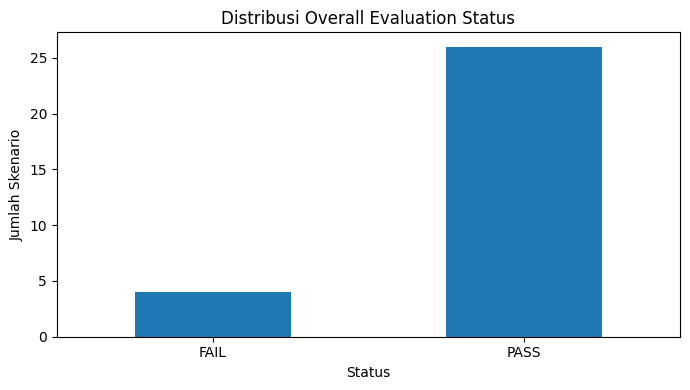

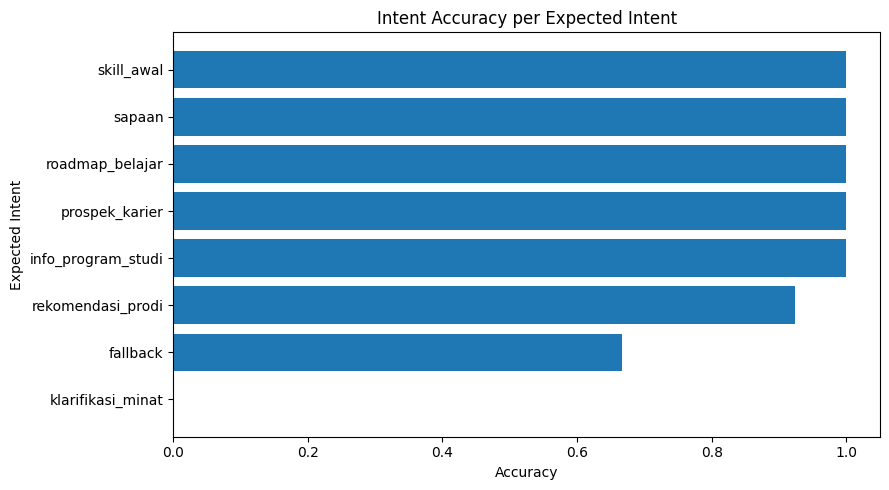

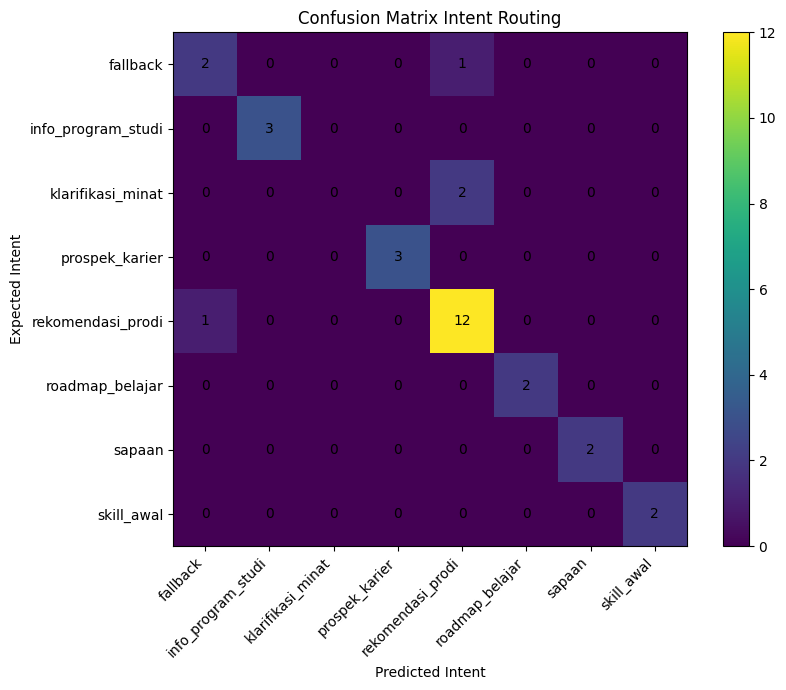

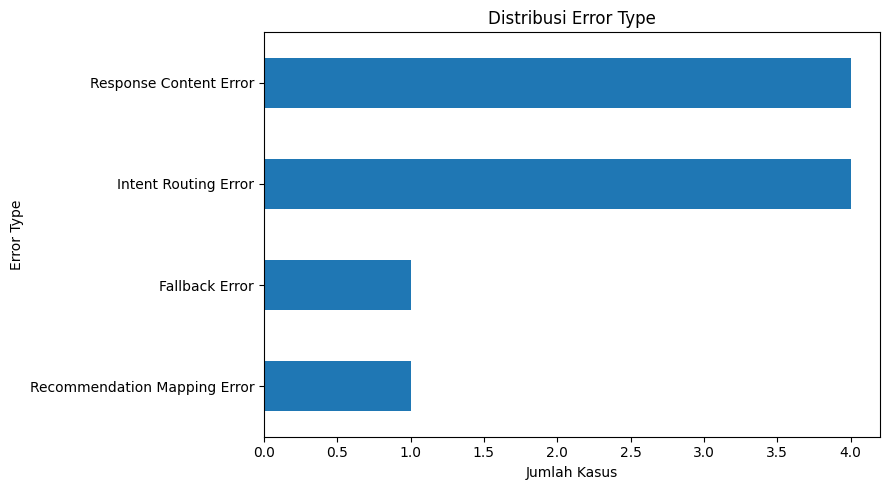

,routing_source,total_cases,avg_model_confidence,avg_rule_confidence,avg_routing_confidence
0,fallback_threshold,3,0.1683,0.0000,0.0000
1,rule_based,27,0.2136,0.7704,0.7704


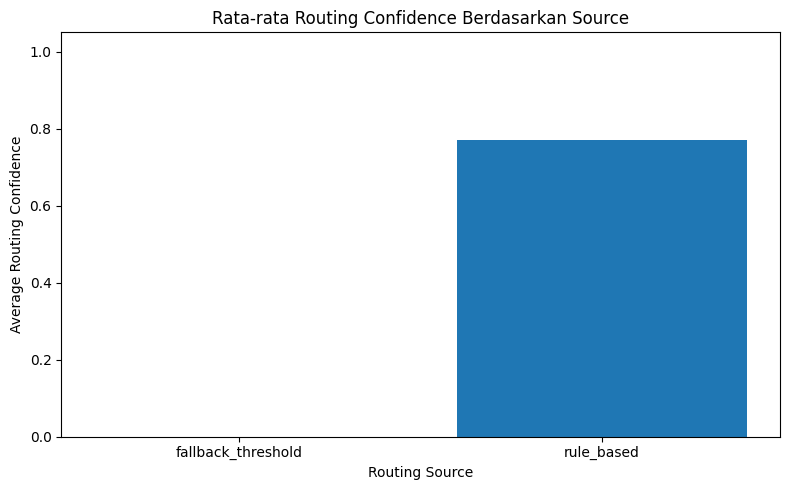

Daftar figure yang berhasil disimpan:
- evaluation_status_distribution.png: reports\stage07\figures\evaluation_status_distribution.png
- intent_accuracy_by_intent.png: reports\stage07\figures\intent_accuracy_by_intent.png
- intent_confusion_matrix.png: reports\stage07\figures\intent_confusion_matrix.png
- error_type_distribution.png: reports\stage07\figures\error_type_distribution.png
- routing_confidence_by_source.png: reports\stage07\figures\routing_confidence_by_source.png


In [9]:
# ============================================================
# 9. Visualisasi Hasil Evaluasi
# ============================================================

figure_paths = {}

def save_figure(filename: str):
    """Menyimpan figure aktif ke folder reports/stage07/figures."""
    path = STAGE07_FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    figure_paths[filename] = str(path.relative_to(PROJECT_ROOT))
    return path


# 1. Distribusi PASS/FAIL
status_counts = evaluation_df["overall_status"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
status_counts.plot(kind="bar")
plt.title("Distribusi Overall Evaluation Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Skenario")
plt.xticks(rotation=0)
save_figure("evaluation_status_distribution.png")


# 2. Intent accuracy per expected intent
intent_plot_df = intent_summary_df.sort_values("intent_accuracy", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(intent_plot_df["expected_intent"], intent_plot_df["intent_accuracy"])
plt.title("Intent Accuracy per Expected Intent")
plt.xlabel("Accuracy")
plt.ylabel("Expected Intent")
plt.xlim(0, 1.05)
save_figure("intent_accuracy_by_intent.png")


# 3. Confusion matrix intent
labels = sorted(
    set(evaluation_df["expected_intent"].astype(str).tolist())
    .union(set(evaluation_df["final_intent"].astype(str).tolist()))
)

cm = confusion_matrix(
    evaluation_df["expected_intent"],
    evaluation_df["final_intent"],
    labels=labels
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix Intent Routing")
plt.xlabel("Predicted Intent")
plt.ylabel("Expected Intent")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

save_figure("intent_confusion_matrix.png")


# 4. Distribusi jenis error
error_type_series = (
    evaluation_df["error_type"]
    .str.split("; ")
    .explode()
    .value_counts()
)

if "OK" in error_type_series.index:
    error_type_series = error_type_series.drop(index="OK")

plt.figure(figsize=(9, 5))
if len(error_type_series) > 0:
    error_type_series.sort_values().plot(kind="barh")
    plt.title("Distribusi Error Type")
    plt.xlabel("Jumlah Kasus")
    plt.ylabel("Error Type")
else:
    plt.text(0.5, 0.5, "Tidak ada error", ha="center", va="center")
    plt.axis("off")
    plt.title("Distribusi Error Type")

save_figure("error_type_distribution.png")


# 5. Rata-rata confidence berdasarkan routing source
confidence_summary_df = (
    evaluation_df
    .groupby("routing_source")
    .agg(
        total_cases=("test_id", "count"),
        avg_model_confidence=("model_confidence", "mean"),
        avg_rule_confidence=("rule_confidence", "mean"),
        avg_routing_confidence=("routing_confidence", "mean")
    )
    .reset_index()
)

for col in ["avg_model_confidence", "avg_rule_confidence", "avg_routing_confidence"]:
    confidence_summary_df[col] = confidence_summary_df[col].round(4)

display(confidence_summary_df)

plt.figure(figsize=(8, 5))
plt.bar(confidence_summary_df["routing_source"], confidence_summary_df["avg_routing_confidence"])
plt.title("Rata-rata Routing Confidence Berdasarkan Source")
plt.xlabel("Routing Source")
plt.ylabel("Average Routing Confidence")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
save_figure("routing_confidence_by_source.png")


print("Daftar figure yang berhasil disimpan:")
for name, path in figure_paths.items():
    print(f"- {name}: {path}")

### Interpretasi Visualisasi

Visualisasi digunakan untuk membantu pembacaan hasil evaluasi secara cepat:

1. **Distribusi PASS/FAIL** menunjukkan keberhasilan fungsional chatbot.
2. **Intent accuracy per intent** membantu melihat intent mana yang paling stabil dan mana yang perlu diperbaiki.
3. **Confusion matrix** menunjukkan pola salah klasifikasi antar intent.
4. **Distribusi error type** menunjukkan jenis masalah yang paling sering muncul.
5. **Routing confidence** membantu menilai apakah keputusan routing cukup stabil.

In [10]:
# ============================================================
# 10. Penyimpanan Output Report Tahap 07
# ============================================================

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

evaluation_results_path = STAGE07_REPORT_DIR / "chatbot_evaluation_results_stage07.csv"
error_analysis_path = STAGE07_REPORT_DIR / "chatbot_error_analysis_stage07.csv"
metrics_path = STAGE07_REPORT_DIR / "chatbot_evaluation_metrics_stage07.csv"
intent_summary_path = STAGE07_REPORT_DIR / "chatbot_intent_summary_stage07.csv"
classification_report_path = STAGE07_REPORT_DIR / "chatbot_intent_classification_report_stage07.csv"
confidence_summary_path = STAGE07_REPORT_DIR / "chatbot_confidence_summary_stage07.csv"
evaluation_report_md_path = STAGE07_REPORT_DIR / "stage07_evaluation_report.md"
summary_path = STAGE07_REPORT_DIR / "stage07_summary.txt"

evaluation_df.to_csv(evaluation_results_path, index=False, encoding="utf-8-sig")
error_analysis_df.to_csv(error_analysis_path, index=False, encoding="utf-8-sig")
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
intent_summary_df.to_csv(intent_summary_path, index=False, encoding="utf-8-sig")
classification_report_df.to_csv(classification_report_path, index=False, encoding="utf-8-sig")
confidence_summary_df.to_csv(confidence_summary_path, index=False, encoding="utf-8-sig")

def df_to_markdown_safe(df: pd.DataFrame) -> str:
    """Konversi dataframe ke markdown dengan fallback jika tabulate tidak tersedia."""
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)

top_errors_text = "Tidak ada error/warning yang ditemukan."
if len(error_analysis_df) > 0:
    top_errors_text = df_to_markdown_safe(
        error_analysis_df[
            [
                "test_id",
                "scenario_group",
                "expected_intent",
                "final_intent",
                "error_type",
                "error_severity"
            ]
        ]
    )

report_lines = []
report_lines.append("# Stage 07 — Chatbot Evaluation, Error Analysis & Scenario Testing")
report_lines.append("")
report_lines.append(f"Generated at: {timestamp}")
report_lines.append("")
report_lines.append("## 1. Ringkasan Metrik")
report_lines.append("")
report_lines.append(df_to_markdown_safe(metrics_df))
report_lines.append("")
report_lines.append("## 2. Ringkasan Per Intent")
report_lines.append("")
report_lines.append(df_to_markdown_safe(intent_summary_df))
report_lines.append("")
report_lines.append("## 3. Error Analysis")
report_lines.append("")
report_lines.append(top_errors_text)
report_lines.append("")
report_lines.append("## 4. Figure Output")
report_lines.append("")

for filename, rel_path in figure_paths.items():
    report_lines.append(f"- `{filename}` → `{rel_path}`")

report_lines.append("")
report_lines.append("## 5. Catatan Evaluasi")
report_lines.append("")
report_lines.append(
    "Evaluasi ini merupakan evaluasi fungsional berbasis skenario. "
    "Hasil evaluasi perlu dibaca bersama dengan keterbatasan dataset, jumlah program studi yang masih terbatas, "
    "dan cakupan normalisasi bahasa yang masih baseline."
)

evaluation_report_md_path.write_text("\n".join(report_lines), encoding="utf-8")

if pd.isna(top_program_accuracy):
    top_program_accuracy_text = "N/A"
else:
    top_program_accuracy_text = f"{top_program_accuracy:.4f}"

summary_text = f"""
TAHAP 07 — Chatbot Evaluation, Error Analysis & Scenario Testing

Project:
EduPath Career Assistant

Generated at:
{timestamp}

Tujuan:
Mengevaluasi pipeline chatbot dari Tahap 06 melalui dataset skenario uji,
pengukuran intent routing, evaluasi isi respons, evaluasi program studi yang direkomendasikan,
error analysis, dan visualisasi hasil evaluasi.

Jumlah skenario uji:
{total_scenarios}

Metrik utama:
1. Intent accuracy              : {intent_accuracy:.4f}
2. Response content accuracy    : {response_content_accuracy:.4f}
3. Top program accuracy         : {top_program_accuracy_text}
4. Overall pass rate            : {overall_pass_rate:.4f}
5. Strict pass rate             : {strict_pass_rate:.4f}
6. Confidence OK rate           : {confidence_ok_rate:.4f}

Jumlah error/warning:
{len(error_analysis_df)}

Output Stage 07:
1. reports/stage07/chatbot_evaluation_scenarios_stage07.csv
2. reports/stage07/chatbot_evaluation_results_stage07.csv
3. reports/stage07/chatbot_error_analysis_stage07.csv
4. reports/stage07/chatbot_evaluation_metrics_stage07.csv
5. reports/stage07/chatbot_intent_summary_stage07.csv
6. reports/stage07/chatbot_intent_classification_report_stage07.csv
7. reports/stage07/chatbot_confidence_summary_stage07.csv
8. reports/stage07/stage07_evaluation_report.md
9. reports/stage07/stage07_summary.txt
10. reports/stage07/figures/

Catatan:
Jika masih terdapat error, gunakan chatbot_error_analysis_stage07.csv sebagai dasar perbaikan dataset,
rule intent routing, normalisasi bahasa, dan template respons chatbot.
""".strip()

summary_path.write_text(summary_text, encoding="utf-8")

print("Output report Stage 07 berhasil disimpan:")
print("-", scenario_path)
print("-", evaluation_results_path)
print("-", error_analysis_path)
print("-", metrics_path)
print("-", intent_summary_path)
print("-", classification_report_path)
print("-", confidence_summary_path)
print("-", evaluation_report_md_path)
print("-", summary_path)

Output report Stage 07 berhasil disimpan:
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_evaluation_scenarios_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_evaluation_results_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_error_analysis_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_evaluation_metrics_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_intent_summary_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_intent_classification_report_stage07.csv
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\chatbot_confidence_summary_stage07.csv
- D:\DATA

### Interpretasi Penyimpanan Output

Output Tahap 07 disimpan dalam bentuk CSV, Markdown, TXT, dan PNG agar mudah digunakan untuk kebutuhan:

- lampiran laporan akademik,
- dokumentasi GitHub,
- audit hasil pengujian chatbot,
- dasar perbaikan pada tahap berikutnya.

File yang paling penting untuk dibaca adalah:

- `stage07_evaluation_report.md`
- `chatbot_error_analysis_stage07.csv`
- `chatbot_evaluation_results_stage07.csv`

In [11]:
# ============================================================
# 11. Checklist File Hasil Tahap 07
# ============================================================

checklist_path = STAGE07_REPORT_DIR / "stage07_output_checklist.csv"

expected_outputs = [
    PROJECT_ROOT / "notebooks" / "07_chatbot_evaluation_error_analysis.ipynb",
    STAGE07_REPORT_DIR / "chatbot_evaluation_scenarios_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_evaluation_results_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_error_analysis_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_evaluation_metrics_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_intent_summary_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_intent_classification_report_stage07.csv",
    STAGE07_REPORT_DIR / "chatbot_confidence_summary_stage07.csv",
    STAGE07_REPORT_DIR / "stage07_evaluation_report.md",
    STAGE07_REPORT_DIR / "stage07_summary.txt",
    STAGE07_FIGURE_DIR / "evaluation_status_distribution.png",
    STAGE07_FIGURE_DIR / "intent_accuracy_by_intent.png",
    STAGE07_FIGURE_DIR / "intent_confusion_matrix.png",
    STAGE07_FIGURE_DIR / "error_type_distribution.png",
    STAGE07_FIGURE_DIR / "routing_confidence_by_source.png",
]

checklist_rows = []

for path in expected_outputs:
    checklist_rows.append({
        "file": str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0
    })

checklist_df = pd.DataFrame(checklist_rows)
checklist_df.to_csv(checklist_path, index=False, encoding="utf-8-sig")

# Tambahkan file checklist itu sendiri setelah berhasil dibuat.
checklist_rows.append({
    "file": str(checklist_path.relative_to(PROJECT_ROOT)),
    "exists": checklist_path.exists(),
    "size_bytes": checklist_path.stat().st_size if checklist_path.exists() else 0
})

checklist_df = pd.DataFrame(checklist_rows)
checklist_df.to_csv(checklist_path, index=False, encoding="utf-8-sig")

display(checklist_df)
print("Checklist disimpan ke:", checklist_path)

if not checklist_df["exists"].all():
    print("Catatan: Jika file notebook Stage 07 belum terdeteksi, pastikan notebook sudah disimpan terlebih dahulu.")
else:
    print("Seluruh output utama Tahap 07 sudah tersedia.")

,file,exists,size_bytes
0,notebooks\07_chatbot_evaluation_error_analysis...,True,382752
1,reports\stage07\chatbot_evaluation_scenarios_s...,True,5538
2,reports\stage07\chatbot_evaluation_results_sta...,True,37406
3,reports\stage07\chatbot_error_analysis_stage07...,True,7063
4,reports\stage07\chatbot_evaluation_metrics_sta...,True,199
5,reports\stage07\chatbot_intent_summary_stage07...,True,312
6,reports\stage07\chatbot_intent_classification_...,True,424
7,reports\stage07\chatbot_confidence_summary_sta...,True,168
8,reports\stage07\stage07_evaluation_report.md,True,2764
9,reports\stage07\stage07_summary.txt,True,1442


Checklist disimpan ke: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage07\stage07_output_checklist.csv
Seluruh output utama Tahap 07 sudah tersedia.


## 12. Kesimpulan Tahap 07

Berdasarkan evaluasi skenario, Tahap 07 menghasilkan beberapa output penting:

1. Dataset skenario uji chatbot yang lebih lengkap.
2. Hasil evaluasi intent routing.
3. Evaluasi kualitas respons chatbot berbasis expected content.
4. Evaluasi kesesuaian program studi yang direkomendasikan.
5. Error analysis untuk mendeteksi kelemahan pipeline.
6. Visualisasi hasil evaluasi.
7. Report dan checklist file hasil.

Secara akademik, tahap ini menunjukkan bahwa chatbot tidak hanya dibangun, tetapi juga diuji, dianalisis, dan didokumentasikan secara sistematis. Jika terdapat error atau warning, hasil error analysis dapat menjadi dasar perbaikan pada tahap berikutnya, misalnya perluasan dataset intent, penambahan rule intent routing, peningkatan normalisasi bahasa, dan penyempurnaan template respons.